# Experiment Comparison Dashboard

Compare multiple training runs side-by-side to see the effect of:
- Different learning rates
- Different number of epochs
- Different dataset sizes
- Different optimizers

**Usage:**
1. Run multiple experiments with different settings
2. Open this notebook
3. Select which experiments to compare
4. View comprehensive comparisons

## 1. Setup

In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Setup complete")

✓ Setup complete


## 2. Load All Experiments

In [4]:
# Load experiments log
experiments_file = '../experiments_log/experiments.json'

if os.path.exists(experiments_file):
    with open(experiments_file, 'r') as f:
        experiments = json.load(f)
    print(f"✓ Loaded {len(experiments)} experiments")
else:
    print("⚠️ No experiments found!")
    print("Run some experiments first:")
    print("  python experiments/train_with_logging.py --name baseline")
    experiments = []

# Display available experiments
if experiments:
    print("\nAvailable Experiments:")
    print("-" * 80)
    for i, exp in enumerate(experiments):
        print(f"{i+1}. {exp['name']} (ID: {exp['id']})")
        print(f"   Config: epochs={exp['config']['epochs']}, "
              f"lr={exp['config']['lr']}, "
              f"samples={exp['config']['train_samples']}")
        print(f"   Best Val AUC: {exp['best_metrics']['auc']:.4f}")
        print()

✓ Loaded 7 experiments

Available Experiments:
--------------------------------------------------------------------------------
1. baseline (ID: baseline_20260105_133744)
   Config: epochs=10, lr=0.001, samples=1000
   Best Val AUC: 0.5639

2. low_lr (ID: low_lr_20260105_152015)
   Config: epochs=10, lr=0.0003, samples=1000
   Best Val AUC: 0.6545

3. high_lr (ID: high_lr_20260105_162457)
   Config: epochs=10, lr=0.003, samples=1000
   Best Val AUC: 0.5769

4. small_batch (ID: small_batch_20260105_135405)
   Config: epochs=10, lr=0.001, samples=1000
   Best Val AUC: 0.5679

5. large_batch (ID: large_batch_20260105_144039)
   Config: epochs=10, lr=0.001, samples=1000
   Best Val AUC: 0.6039

6. low_data (ID: low_data_20260105_150706)
   Config: epochs=10, lr=0.001, samples=500
   Best Val AUC: 0.6076

7. more_data (ID: more_data_20260105_165457)
   Config: epochs=10, lr=0.001, samples=2000
   Best Val AUC: 0.5409



## 3. Select Experiments to Compare

Choose which experiments you want to compare (by name or index)

In [5]:
# OPTION 1: Compare by name
experiment_names = ['baseline', 'low_lr', 'high_lr', 'small_batch', 'large_batch', 'low_data', 'more_data']  # Modify these!

# OPTION 2: Compare by index (1-based)
# experiment_indices = [1, 2, 3]  # Uncomment and modify!

# Filter experiments
if 'experiment_names' in locals():
    selected_experiments = [exp for exp in experiments if any(name in exp['name'] for name in experiment_names)]
elif 'experiment_indices' in locals():
    selected_experiments = [experiments[i-1] for i in experiment_indices if i <= len(experiments)]
else:
    # Default: compare all experiments
    selected_experiments = experiments

print(f"Comparing {len(selected_experiments)} experiments:")
for exp in selected_experiments:
    print(f"  - {exp['name']}")

Comparing 7 experiments:
  - baseline
  - low_lr
  - high_lr
  - small_batch
  - large_batch
  - low_data
  - more_data


## 4. Comparison Summary Table

In [6]:
# Create summary dataframe
summary_data = []
for exp in selected_experiments:
    summary_data.append({
        'Name': exp['name'],
        'Epochs': exp['config']['epochs'],
        'LR': exp['config']['lr'],
        'Batch Size': exp['config']['batch_size'],
        'Train Samples': exp['config']['train_samples'],
        'Optimizer': exp['config'].get('optimizer', 'adam'),
        'Best Val AUC': exp['best_metrics']['auc'],
        'Best Val Acc': exp['best_metrics']['accuracy'],
        'Sensitivity': exp['best_metrics']['sensitivity'],
        'Specificity': exp['best_metrics']['specificity'],
        'Time (min)': exp['elapsed_time'] / 60,
        'Time/Epoch (min)': exp['time_per_epoch'] / 60
    })

summary_df = pd.DataFrame(summary_data)

# Style the dataframe
styled_summary = summary_df.style.background_gradient(subset=['Best Val AUC'], cmap='YlGn')\
                                 .background_gradient(subset=['Time (min)'], cmap='YlOrRd_r')\
                                 .format({
                                     'LR': '{:.1e}',
                                     'Best Val AUC': '{:.4f}',
                                     'Best Val Acc': '{:.4f}',
                                     'Sensitivity': '{:.4f}',
                                     'Specificity': '{:.4f}',
                                     'Time (min)': '{:.1f}',
                                     'Time/Epoch (min)': '{:.2f}'
                                 })

display(styled_summary)

# Save to CSV
summary_df.to_csv('../results/experiment_comparison.csv', index=False)
print("\n✓ Summary saved to: results/experiment_comparison.csv")

,Name,Epochs,LR,Batch Size,Train Samples,Optimizer,Best Val AUC,Best Val Acc,Sensitivity,Specificity,Time (min),Time/Epoch (min)
0,baseline,10,1.0e-03,4,1000,adam,0.5639,0.5000,1.0000,0.0000,47.4,4.74
1,low_lr,10,3.0e-04,4,1000,adam,0.6545,0.5250,0.9300,0.1200,74.9,7.49
2,high_lr,10,3.0e-03,4,1000,adam,0.5769,0.5000,1.0000,0.0000,55.9,5.59
3,small_batch,10,1.0e-03,2,1000,adam,0.5679,0.5250,0.8900,0.1600,40.0,4.00
4,large_batch,10,1.0e-03,8,1000,adam,0.6039,0.5150,0.7900,0.2400,43.8,4.38
5,low_data,10,1.0e-03,4,500,adam,0.6076,0.5000,1.0000,0.0000,23.6,2.36
6,more_data,10,1.0e-03,4,2000,adam,0.5409,0.5000,1.0000,0.0000,105.8,10.58



✓ Summary saved to: results/experiment_comparison.csv


## 5. Training Curves Comparison

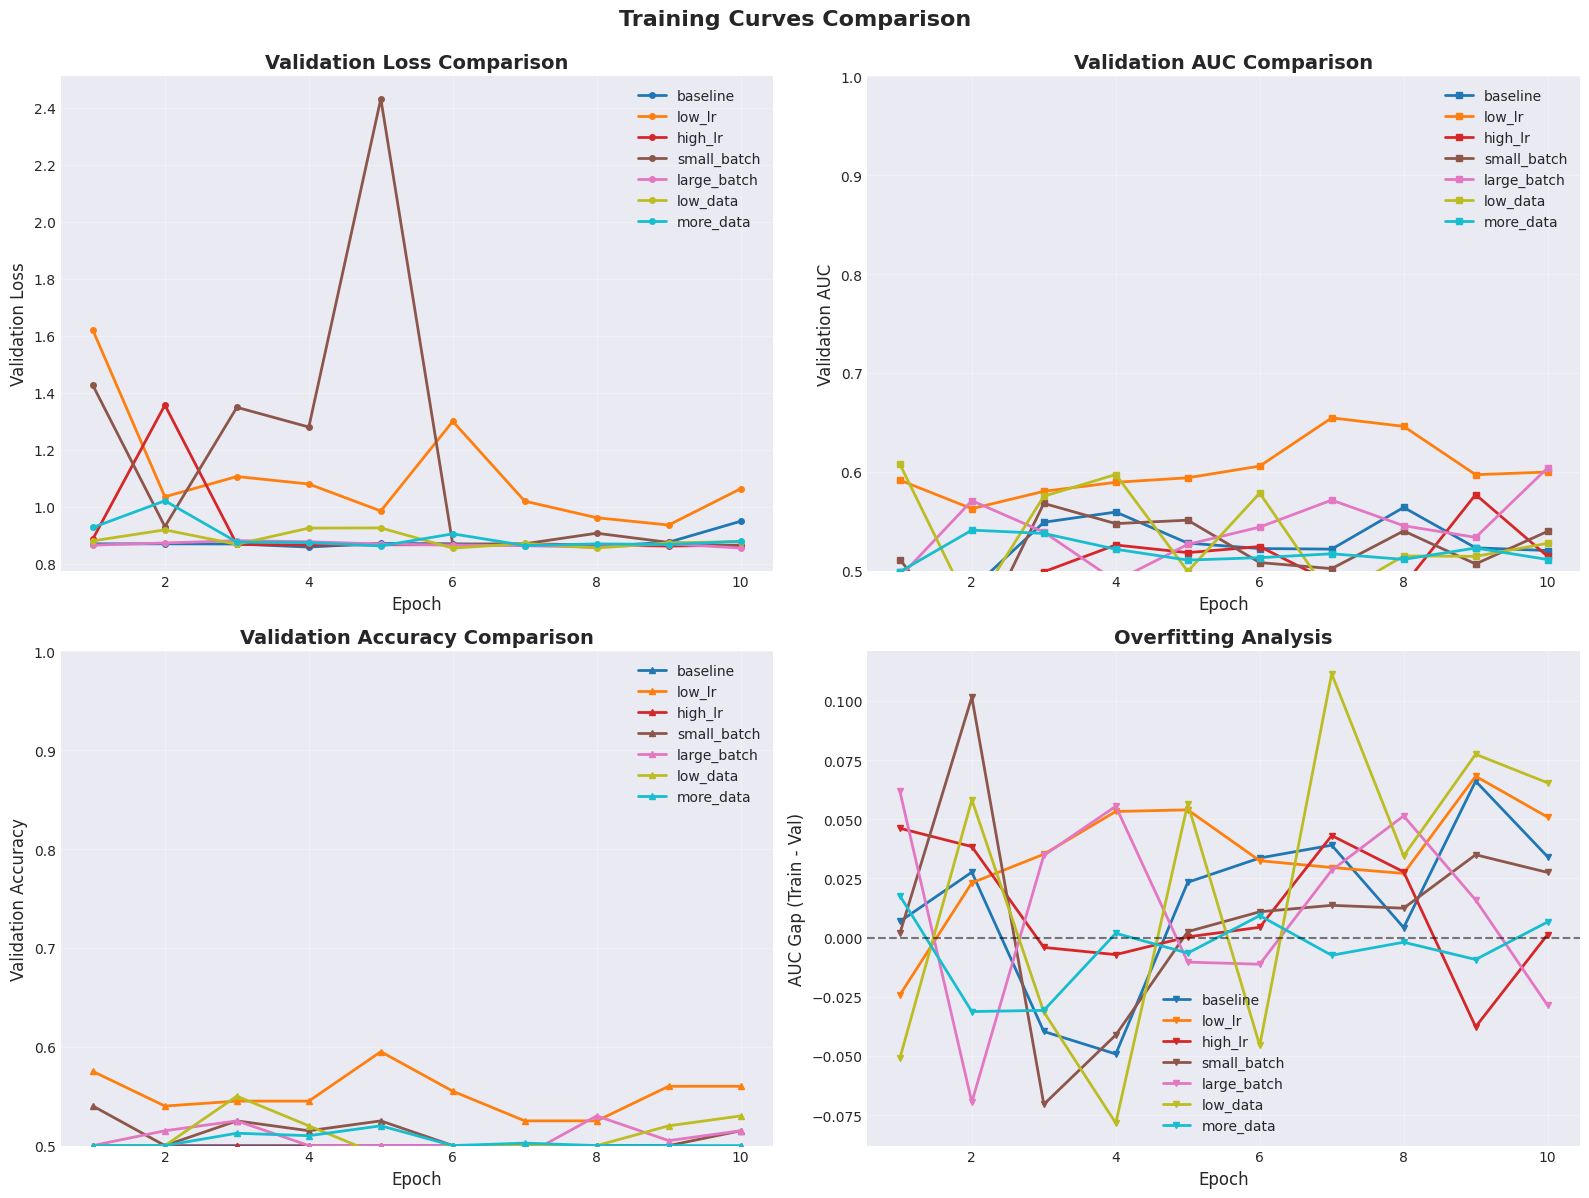

✓ Training curves compared


In [7]:
# Plot training curves for all experiments
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = plt.cm.tab10(np.linspace(0, 1, len(selected_experiments)))

for i, exp in enumerate(selected_experiments):
    history = exp['history']
    epochs = range(1, len(history['train_loss']) + 1)
    label = exp['name']
    
    # Validation Loss
    axes[0, 0].plot(epochs, history['val_loss'], marker='o', label=label, 
                    linewidth=2, color=colors[i], markersize=4)
    
    # Validation AUC
    axes[0, 1].plot(epochs, history['val_auc'], marker='s', label=label,
                    linewidth=2, color=colors[i], markersize=4)
    
    # Validation Accuracy
    axes[1, 0].plot(epochs, history['val_acc'], marker='^', label=label,
                    linewidth=2, color=colors[i], markersize=4)
    
    # Train/Val AUC Gap (overfitting)
    auc_gap = np.array(history['train_auc']) - np.array(history['val_auc'])
    axes[1, 1].plot(epochs, auc_gap, marker='v', label=label,
                    linewidth=2, color=colors[i], markersize=4)

# Styling
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Validation Loss', fontsize=12)
axes[0, 0].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Validation AUC', fontsize=12)
axes[0, 1].set_title('Validation AUC Comparison', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.5, 1.0])

axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Validation Accuracy', fontsize=12)
axes[1, 0].set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.5, 1.0])

axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('AUC Gap (Train - Val)', fontsize=12)
axes[1, 1].set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training Curves Comparison', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../results/training_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training curves compared")

## 6. Final Performance Comparison

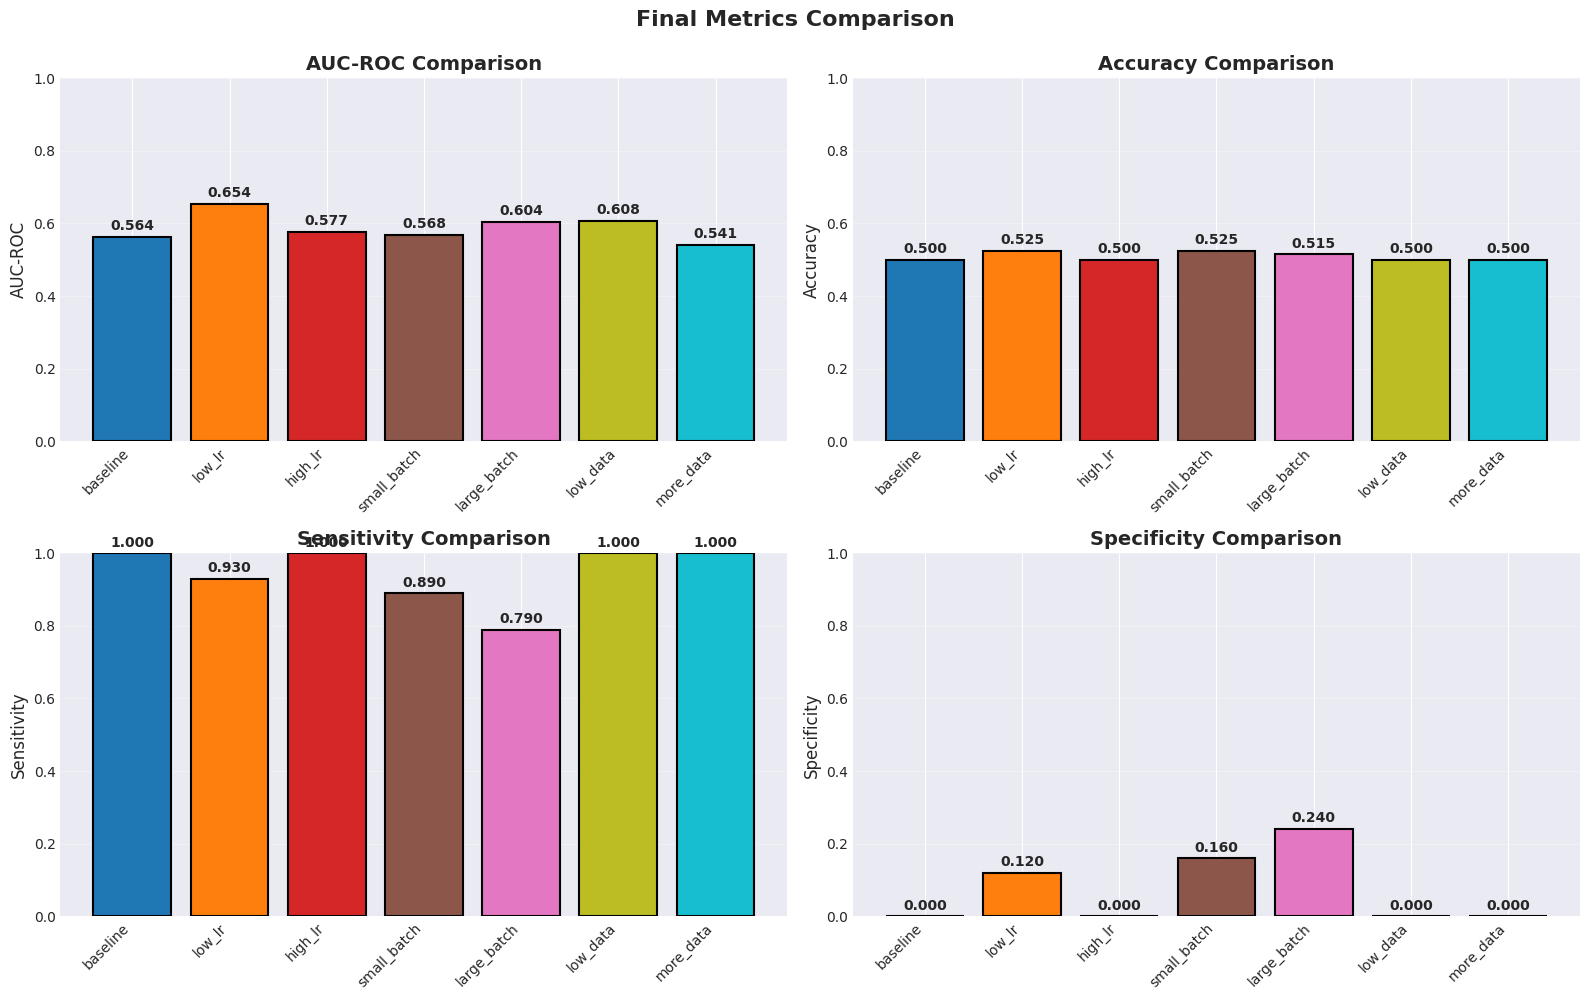

✓ Final metrics compared


In [8]:
# Bar charts for final metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics_to_plot = [
    ('Best Val AUC', 'AUC-ROC'),
    ('Best Val Acc', 'Accuracy'),
    ('Sensitivity', 'Sensitivity'),
    ('Specificity', 'Specificity')
]

for idx, (metric, title) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    values = summary_df[metric].values
    names = summary_df['Name'].values
    
    bars = ax.bar(range(len(names)), values, color=colors[:len(names)], edgecolor='black', linewidth=1.5)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_ylabel(title, fontsize=12)
    ax.set_title(f'{title} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Final Metrics Comparison', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../results/final_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Final metrics compared")

## 7. Hyperparameter Effect Analysis

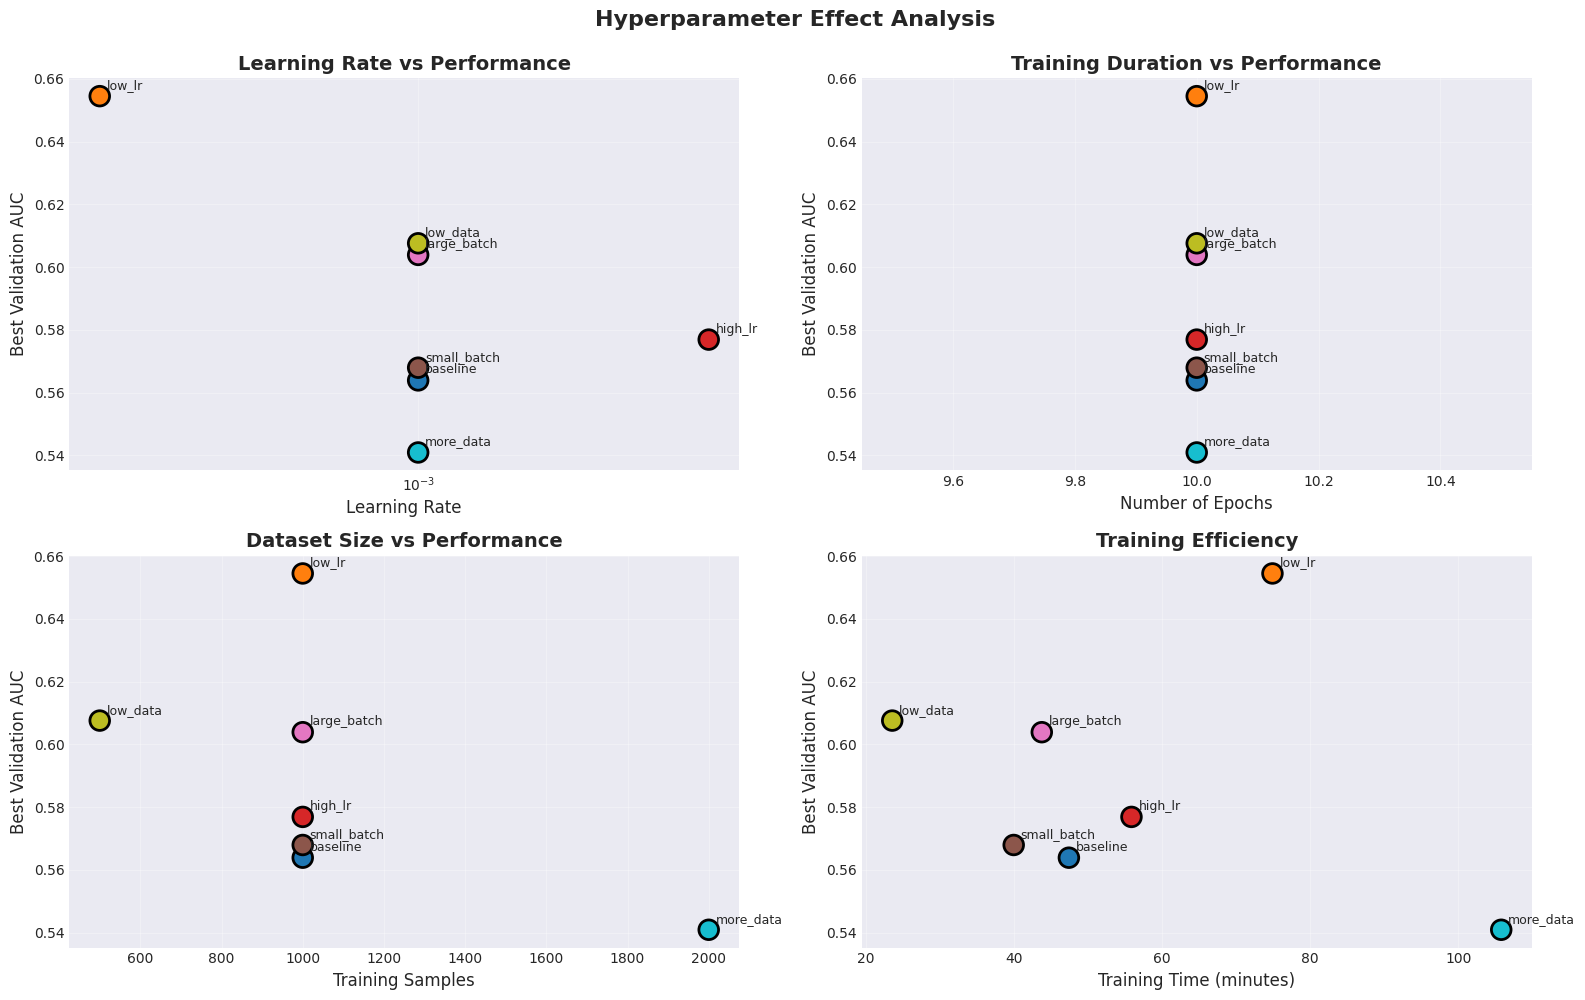

✓ Hyperparameter effects analyzed


In [9]:
# Analyze effect of different hyperparameters
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Learning Rate vs AUC
axes[0, 0].scatter(summary_df['LR'], summary_df['Best Val AUC'], 
                   s=200, c=colors[:len(summary_df)], edgecolors='black', linewidth=2)
for i, name in enumerate(summary_df['Name']):
    axes[0, 0].annotate(name, (summary_df['LR'].iloc[i], summary_df['Best Val AUC'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[0, 0].set_xlabel('Learning Rate', fontsize=12)
axes[0, 0].set_ylabel('Best Validation AUC', fontsize=12)
axes[0, 0].set_title('Learning Rate vs Performance', fontsize=14, fontweight='bold')
axes[0, 0].set_xscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Epochs vs AUC
axes[0, 1].scatter(summary_df['Epochs'], summary_df['Best Val AUC'],
                   s=200, c=colors[:len(summary_df)], edgecolors='black', linewidth=2)
for i, name in enumerate(summary_df['Name']):
    axes[0, 1].annotate(name, (summary_df['Epochs'].iloc[i], summary_df['Best Val AUC'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[0, 1].set_xlabel('Number of Epochs', fontsize=12)
axes[0, 1].set_ylabel('Best Validation AUC', fontsize=12)
axes[0, 1].set_title('Training Duration vs Performance', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Training Samples vs AUC
axes[1, 0].scatter(summary_df['Train Samples'], summary_df['Best Val AUC'],
                   s=200, c=colors[:len(summary_df)], edgecolors='black', linewidth=2)
for i, name in enumerate(summary_df['Name']):
    axes[1, 0].annotate(name, (summary_df['Train Samples'].iloc[i], summary_df['Best Val AUC'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[1, 0].set_xlabel('Training Samples', fontsize=12)
axes[1, 0].set_ylabel('Best Validation AUC', fontsize=12)
axes[1, 0].set_title('Dataset Size vs Performance', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Training Time vs AUC (efficiency)
axes[1, 1].scatter(summary_df['Time (min)'], summary_df['Best Val AUC'],
                   s=200, c=colors[:len(summary_df)], edgecolors='black', linewidth=2)
for i, name in enumerate(summary_df['Name']):
    axes[1, 1].annotate(name, (summary_df['Time (min)'].iloc[i], summary_df['Best Val AUC'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[1, 1].set_xlabel('Training Time (minutes)', fontsize=12)
axes[1, 1].set_ylabel('Best Validation AUC', fontsize=12)
axes[1, 1].set_title('Training Efficiency', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Hyperparameter Effect Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../results/hyperparameter_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Hyperparameter effects analyzed")

## 8. Best Experiment Identification

In [10]:
# Find best experiments by different criteria
print("="*70)
print("BEST EXPERIMENTS BY CRITERIA")
print("="*70)

# Best AUC
best_auc_idx = summary_df['Best Val AUC'].idxmax()
print(f"\n🏆 Best AUC: {summary_df.loc[best_auc_idx, 'Name']}")
print(f"   AUC: {summary_df.loc[best_auc_idx, 'Best Val AUC']:.4f}")
print(f"   Config: epochs={summary_df.loc[best_auc_idx, 'Epochs']}, "
      f"lr={summary_df.loc[best_auc_idx, 'LR']:.1e}, "
      f"samples={summary_df.loc[best_auc_idx, 'Train Samples']}")

# Best Accuracy
best_acc_idx = summary_df['Best Val Acc'].idxmax()
print(f"\n🎯 Best Accuracy: {summary_df.loc[best_acc_idx, 'Name']}")
print(f"   Accuracy: {summary_df.loc[best_acc_idx, 'Best Val Acc']:.4f}")

# Fastest Training
fastest_idx = summary_df['Time (min)'].idxmin()
print(f"\n⚡ Fastest Training: {summary_df.loc[fastest_idx, 'Name']}")
print(f"   Time: {summary_df.loc[fastest_idx, 'Time (min)']:.1f} minutes")
print(f"   AUC: {summary_df.loc[fastest_idx, 'Best Val AUC']:.4f}")

# Best Efficiency (AUC per minute)
summary_df['Efficiency'] = summary_df['Best Val AUC'] / summary_df['Time (min)']
best_eff_idx = summary_df['Efficiency'].idxmax()
print(f"\n💡 Most Efficient: {summary_df.loc[best_eff_idx, 'Name']}")
print(f"   AUC/min: {summary_df.loc[best_eff_idx, 'Efficiency']:.4f}")
print(f"   AUC: {summary_df.loc[best_eff_idx, 'Best Val AUC']:.4f} in {summary_df.loc[best_eff_idx, 'Time (min)']:.1f} min")

# Best Balance (Sensitivity + Specificity)
summary_df['Balance'] = (summary_df['Sensitivity'] + summary_df['Specificity']) / 2
best_bal_idx = summary_df['Balance'].idxmax()
print(f"\n⚖️  Best Balance: {summary_df.loc[best_bal_idx, 'Name']}")
print(f"   Sensitivity: {summary_df.loc[best_bal_idx, 'Sensitivity']:.4f}")
print(f"   Specificity: {summary_df.loc[best_bal_idx, 'Specificity']:.4f}")

print("\n" + "="*70)

BEST EXPERIMENTS BY CRITERIA

🏆 Best AUC: low_lr
   AUC: 0.6545
   Config: epochs=10, lr=3.0e-04, samples=1000

🎯 Best Accuracy: low_lr
   Accuracy: 0.5250

⚡ Fastest Training: low_data
   Time: 23.6 minutes
   AUC: 0.6076

💡 Most Efficient: low_data
   AUC/min: 0.0257
   AUC: 0.6076 in 23.6 min

⚖️  Best Balance: low_lr
   Sensitivity: 0.9300
   Specificity: 0.1200



## 9. Generate Comparison Report

In [11]:
# Generate markdown report
report_path = '../results/experiment_comparison_report.md'

with open(report_path, 'w') as f:
    f.write("# Experiment Comparison Report\n\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("## Experiments Compared\n\n")
    for exp in selected_experiments:
        f.write(f"- **{exp['name']}** ({exp['id']})\n")
    
    f.write("\n## Summary Table\n\n")
    f.write(summary_df.to_markdown(index=False))
    
    f.write("\n\n## Best Performers\n\n")
    f.write(f"### Best AUC: {summary_df.loc[best_auc_idx, 'Name']}\n")
    f.write(f"- AUC: {summary_df.loc[best_auc_idx, 'Best Val AUC']:.4f}\n")
    f.write(f"- Accuracy: {summary_df.loc[best_auc_idx, 'Best Val Acc']:.4f}\n\n")
    
    f.write(f"### Most Efficient: {summary_df.loc[best_eff_idx, 'Name']}\n")
    f.write(f"- AUC per minute: {summary_df.loc[best_eff_idx, 'Efficiency']:.4f}\n")
    f.write(f"- Total time: {summary_df.loc[best_eff_idx, 'Time (min)']:.1f} min\n\n")
    
    f.write("## Visualizations\n\n")
    f.write("![Training Curves](training_curves_comparison.png)\n\n")
    f.write("![Final Metrics](final_metrics_comparison.png)\n\n")
    f.write("![Hyperparameter Analysis](hyperparameter_analysis.png)\n\n")
    
    f.write("## Key Findings\n\n")
    
    # Automatic insights
    lr_range = summary_df['LR'].max() / summary_df['LR'].min()
    if lr_range > 5:
        f.write(f"- Learning rate varied by {lr_range:.1f}x across experiments\n")
    
    auc_improvement = summary_df['Best Val AUC'].max() - summary_df['Best Val AUC'].min()
    f.write(f"- AUC improvement range: {auc_improvement:.4f}\n")
    
    time_diff = summary_df['Time (min)'].max() - summary_df['Time (min)'].min()
    f.write(f"- Training time difference: {time_diff:.1f} minutes\n")

print(f"✓ Comparison report generated: {report_path}")

ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

## 📌 Summary

**This notebook allows you to:**
- Compare multiple training runs side-by-side
- Visualize the effect of hyperparameters
- Identify best configurations
- Generate comparison reports

**Next steps:**
1. Run more experiments with different settings
2. Use insights to optimize your configuration
3. Pick the best model for your use case
4. Include visualizations in your report/article